In [26]:
%load_ext autoreload
%autoreload 2

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from DataCollapse import *
from src.fss.data_collapse import DataCollapse


# Generate pseudo data

In [4]:
def generate_pseudo_data(pc=0.5,p_list=np.round(np.linspace(0.45,.55,11),2),nu=1,L_list=np.arange(10,20,2),beta=0.5, f=lambda x: (1-x)**(1/2),seed=0, epsilon=0.01,N=100):
    """Generate pseudo data following y~L^{-beta/nu} f[(p-p_c)L^{1/nu}] + epsilon, where epsilon is a random noise, N is the sample size"""
    rng=np.random.default_rng(seed)
    data_dict={(p,L): L**(-beta/nu)*f((p-pc)* L **(1/nu))+ rng.normal(0,epsilon,N) for L in L_list for p in p_list}
    index = pd.MultiIndex.from_tuples([key for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': data_dict.values()}, index=index)
    return df
    

In [5]:
# Generate psudo data with p_c=0.5, nu=1, beta=0.5
df=generate_pseudo_data(pc=0.5,nu=1,beta=0.5)

In [8]:
df.head()

,,observations
p,L,
0.45,10,"[0.3885556368316756, 0.38597728598782866, 0.39..."
0.46,10,"[0.3791925671761428, 0.3840628690102522, 0.372..."
0.47,10,"[0.35391977556335846, 0.35442094906025867, 0.3..."
0.48,10,"[0.3584427510549405, 0.35278089387003736, 0.35..."
0.49,10,"[0.328058077325631, 0.3374978203093675, 0.3172..."


In [40]:
df['estimator']=df['observations'].apply(np.mean)
df['standard_error']=df['observations'].apply(lambda x: np.std(x)/np.sqrt(len(x)))
df[['estimator','standard_error']].head()

,,estimator,standard_error
p,L,,
0.45,10,0.388109,0.000962
0.46,10,0.373660,0.000956
0.47,10,0.359175,0.001116
0.48,10,0.346020,0.000924
0.49,10,0.331783,0.001084


# Load data

In [32]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

## Plot the raw data

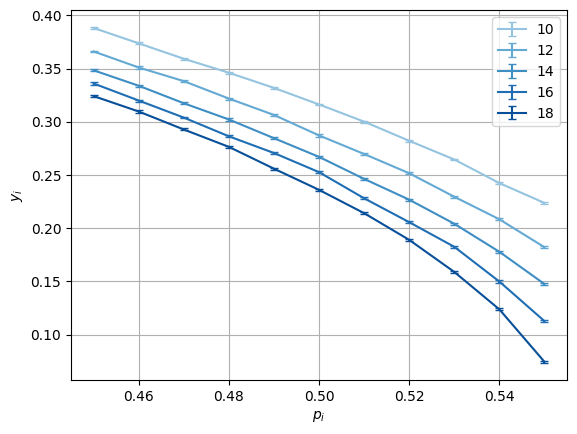

In [33]:
dc.plot_data_collapse(raw=True, errorbar=True)

# Finite size scaling

In [34]:
dc.datacollapse(p_c=0.505,nu=1.3,beta=0.0,p_c_vary=True,beta_vary=True,nu_vary=True)

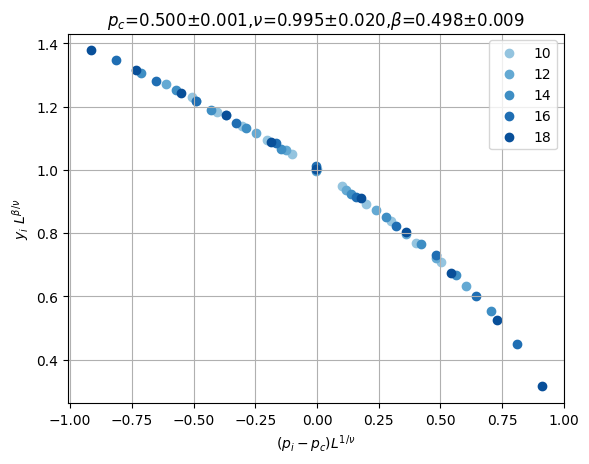

In [35]:
dc.plot_data_collapse()

# Load data with `estimator='manual'` 

In [41]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],estimator='manual',)

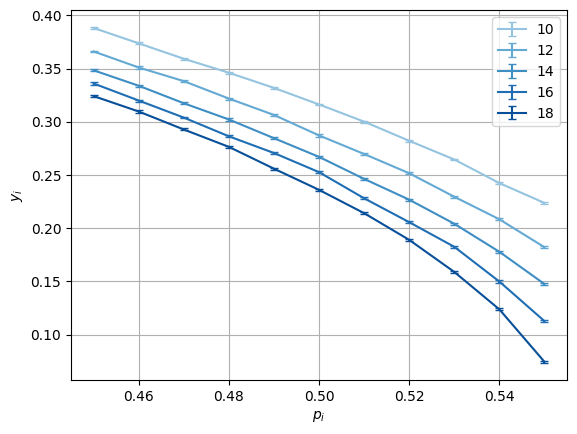

In [42]:
dc.plot_data_collapse(raw=True, errorbar=True)